<a href="https://colab.research.google.com/github/iiLolaii/data-management-262/blob/main/gsheet_script_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gspread google-auth

In [ ]:
from google.colab import auth

In [ ]:
auth.authenticate_user()

In [ ]:
import gspread
from google.auth import default
import pandas as pd

In [ ]:
creds, _ = default()
gc = gspread.authorize(creds)

In [ ]:
sh = gc.open("spreadsheet_reformat_test")
wks = sh.sheet1
records = wks.get_all_records()

In [ ]:
df = pd.DataFrame(records)
df.head()

,doi_url,title,author,journal_name,publication_year,primary_sources,secondary_sources,geographic_location,language,dialect,data_deposited,data_deposit_doi_url,data_repository_format,funding_source
0,https://doi.org/10.1017/S0142716423000243,The impact of dialect differences on spoken la...,Arynn S. Byrd; Yi Ting Huang; Jan Edwards\n,Applied Psycholinguistics,2023,dataset,n/a,usa,english,african american english (aae)\nmainstream ame...,other (replication package),https://osf.io/w7jhs,OSF,Institute of Education Sciences;\nNational Sci...
1,https://doi.org/10.3390/languages6010040,"Language, or Dialect, That Is the Question. Ho...",Astrid Adler,Languages,2021,survey,interview; scholarly article,germany,german,low german,upon request,https://www.diw.de/en/diw_01.c.601584.en/data_...,Website,n/a
2,https://doi.org/10.3390/languages10090242,When Pitch Falls Short: Reinforcing Prosodic B...,Marta Ortega-Llebaria; Jun Nagao,Languages,2025,study,scholarly article,usa; japan,japanese,various: kobayashi; koriyama; tokyo; osaka; no...,si (zip file download),https://www.mdpi.com/article/10.3390/languages...,PDF,Hewlett International Grant; University of Pit...
3,https://doi.org/10.3390/languages10090225,Russian–Belarusian Border Dialects and Their “...,Anastasiia Ryko\n,Languages,2025,study; interview,scholarly article,estonia,russian; belarusian,various: mogilev–smolensk; khislavichy; trasia...,other,https://lingconlab.ru/khislavichi/#!/,Website,n/a
4,https://doi.org/10.3390/languages10080188,Language Contact and Population Contact as Sou...,Jonathan Dunn; Sidney Wong,Languages,2025,study,study; scholarly article,usa; new zealand,english,n/a,repository,https://doi.org/10.17605/OSF.IO/GD2KQ,OSF,n/a


In [ ]:
#standardizing capitalization and separating commas
lowercase_col = ['primary_sources','secondary_sources','geographic_location','language','dialect','data_deposited']
semicolon_replace = df.drop(columns=['doi_url','title','journal_name','publication_year'])

for col in lowercase_col:
  df[col] = df[col].str.lower()

for col in semicolon_replace:
  df[col] = df[col].str.replace(', ',';')

df.head()

,doi_url,title,author,journal_name,publication_year,primary_sources,secondary_sources,geographic_location,language,dialect,data_deposited,data_deposit_doi_url,data_repository_format,funding_source
0,https://doi.org/10.1017/S0142716423000243,The impact of dialect differences on spoken la...,Arynn S. Byrd;Yi Ting Huang;Jan Edwards\n,Applied Psycholinguistics,2023,dataset,n/a,usa,english,african american english (aae)\nmainstream ame...,other (replication package),https://osf.io/w7jhs,OSF,Institute of Education Sciences;\nNational Sci...
1,https://doi.org/10.3390/languages6010040,"Language, or Dialect, That Is the Question. Ho...",Astrid Adler,Languages,2021,survey,interview;scholarly article,germany,german,low german,upon request,https://www.diw.de/en/diw_01.c.601584.en/data_...,Website,n/a
2,https://doi.org/10.3390/languages10090242,When Pitch Falls Short: Reinforcing Prosodic B...,Marta Ortega-Llebaria;Jun Nagao,Languages,2025,study,scholarly article,usa;japan,japanese,various: kobayashi;koriyama;tokyo;osaka;northe...,si (zip file download),https://www.mdpi.com/article/10.3390/languages...,PDF,Hewlett International Grant;University of Pitt...
3,https://doi.org/10.3390/languages10090225,Russian–Belarusian Border Dialects and Their “...,Anastasiia Ryko\n,Languages,2025,study;interview,scholarly article,estonia,russian;belarusian,various: mogilev–smolensk;khislavichy;trasiank...,other,https://lingconlab.ru/khislavichi/#!/,Website,n/a
4,https://doi.org/10.3390/languages10080188,Language Contact and Population Contact as Sou...,Jonathan Dunn;Sidney Wong,Languages,2025,study,study;scholarly article,usa;new zealand,english,n/a,repository,https://doi.org/10.17605/OSF.IO/GD2KQ,OSF,n/a


In [ ]:
#primary source split value count

split_primary_sources = df['primary_sources'].str.split(';')
exploded_primary_sources = split_primary_sources.explode()

exploded_primary_sources.value_counts()

,count
primary_sources,
dataset,19
study,9
experiment,5
survey,2
interview,1
sruvey,1
n/a,1


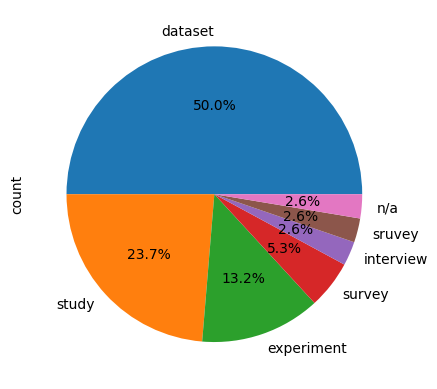

In [ ]:
import matplotlib.pyplot as plt

primary_counts = exploded_primary_sources.value_counts()

primary_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    )

plt.show()

In [ ]:
#secondary sources split value count

split_secondary_sources = df['secondary_sources'].str.split(';')
exploded_secondary_sources = split_secondary_sources.explode()

exploded_secondary_sources.value_counts()

,count
secondary_sources,
scholarly article,28
study,3
interview,1
n/a,1


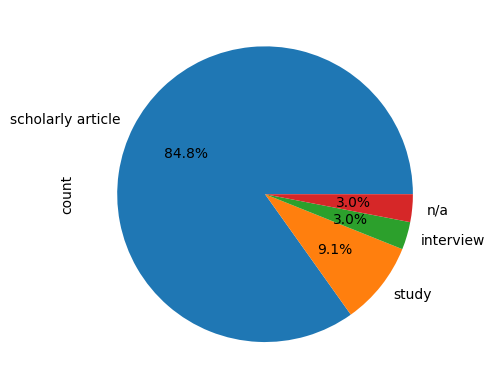

In [ ]:
secondary_counts = exploded_secondary_sources.value_counts()

secondary_counts.plot(
    kind="pie",
    autopct='%1.1f%%',
)

plt.show()

In [ ]:
data = [df.columns.values.tolist()] + df.values.tolist()
wks.update(data)

{'spreadsheetId': '1KQ3T2-cHp8PCpT3cdMCw6ILi4MmawOW1FToVJ-lMp78',
 'updatedRange': 'Sheet1!A1:N30',
 'updatedRows': 30,
 'updatedColumns': 14,
 'updatedCells': 420}